In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [2]:
df=pd.read_csv("iris.csv")

In [3]:
df.drop("Id",inplace=True,axis=1)

In [4]:
df.head(3)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa


In [5]:
df.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [7]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 2  Exploratory Data analysis

In [8]:
df["SepalLengthCm"].nunique()

35

In [9]:
df.SepalLengthCm.unique()

array([5.1, 4.9, 4.7, 4.6, 5. , 5.4, 4.4, 4.8, 4.3, 5.8, 5.7, 5.2, 5.5,
       4.5, 5.3, 7. , 6.4, 6.9, 6.5, 6.3, 6.6, 5.9, 6. , 6.1, 5.6, 6.7,
       6.2, 6.8, 7.1, 7.6, 7.3, 7.2, 7.7, 7.4, 7.9])

In [10]:
df.SepalWidthCm.nunique()

23

In [11]:
df.SepalWidthCm.unique()


array([3.5, 3. , 3.2, 3.1, 3.6, 3.9, 3.4, 2.9, 3.7, 4. , 4.4, 3.8, 3.3,
       4.1, 4.2, 2.3, 2.8, 2.4, 2.7, 2. , 2.2, 2.5, 2.6])

In [12]:
df.PetalLengthCm.nunique()

43

In [13]:
df.PetalLengthCm.unique()

array([1.4, 1.3, 1.5, 1.7, 1.6, 1.1, 1.2, 1. , 1.9, 4.7, 4.5, 4.9, 4. ,
       4.6, 3.3, 3.9, 3.5, 4.2, 3.6, 4.4, 4.1, 4.8, 4.3, 5. , 3.8, 3.7,
       5.1, 3. , 6. , 5.9, 5.6, 5.8, 6.6, 6.3, 6.1, 5.3, 5.5, 6.7, 6.9,
       5.7, 6.4, 5.4, 5.2])

In [14]:
df.Species.nunique()

3

In [15]:
df.Species.unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

##  3  Feature Engineering

In [16]:
df.Species.value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [17]:
df.Species.value_counts().to_dict()

{'Iris-setosa': 50, 'Iris-versicolor': 50, 'Iris-virginica': 50}

In [18]:
df["Species"].replace({'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2},inplace=True)

In [19]:
df.head(3)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [21]:
df.Species.value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

## 4  Feature Selection

In [22]:
df.corr()


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
SepalLengthCm,1.000000,-0.109369,0.871754,0.817954,0.782561
SepalWidthCm,-0.109369,1.000000,-0.420516,-0.356544,-0.419446
PetalLengthCm,0.871754,-0.420516,1.000000,0.962757,0.949043
PetalWidthCm,0.817954,-0.356544,0.962757,1.000000,0.956464
Species,0.782561,-0.419446,0.949043,0.956464,1.000000


C:\Users\vivek\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 60x60 with 0 Axes>

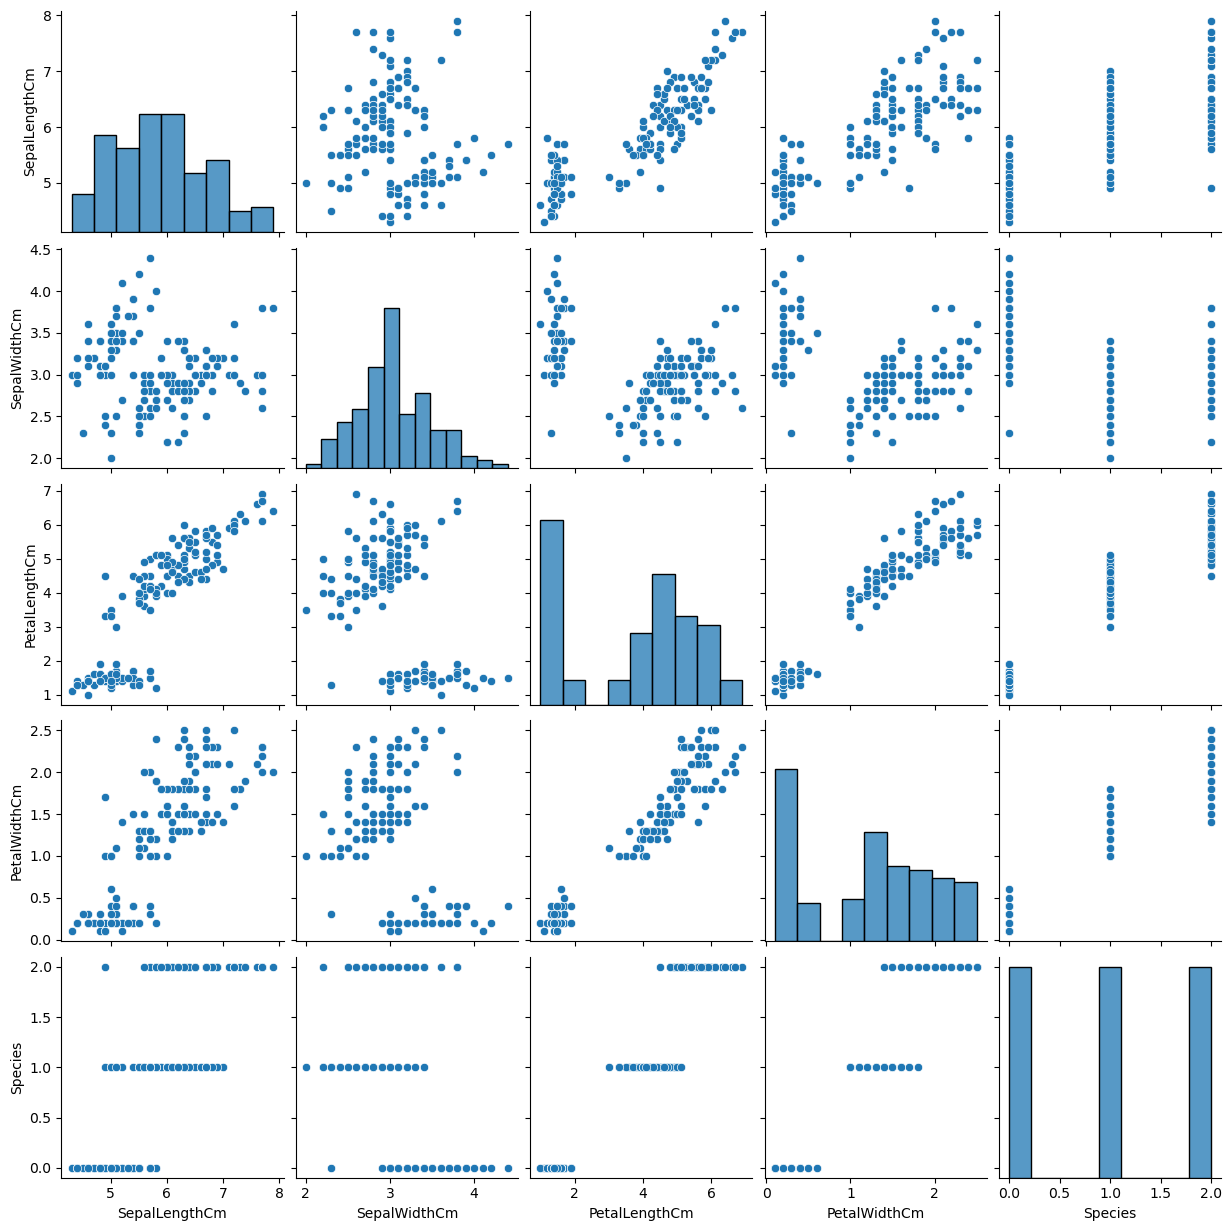

In [23]:
plt.figure(figsize=(3,3),dpi=20)
sns.pairplot(df)
plt.show()

<Axes: >

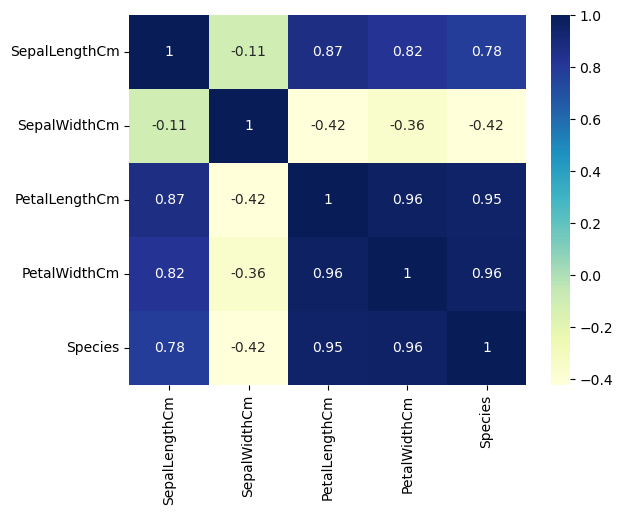

In [24]:
sns.heatmap(df.corr(),annot=True,cbar=True,cmap="YlGnBu")

## 4.1 check multicolinearity

In [25]:
df1=df.drop("SepalLengthCm",axis=1)
df1.head()


,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,3.5,1.4,0.2,0
1,3.0,1.4,0.2,0
2,3.2,1.3,0.2,0
3,3.1,1.5,0.2,0
4,3.6,1.4,0.2,0


In [26]:
df1.to_numpy()

array([[3.5, 1.4, 0.2, 0. ],
       [3. , 1.4, 0.2, 0. ],
       [3.2, 1.3, 0.2, 0. ],
       [3.1, 1.5, 0.2, 0. ],
       [3.6, 1.4, 0.2, 0. ],
       [3.9, 1.7, 0.4, 0. ],
       [3.4, 1.4, 0.3, 0. ],
       [3.4, 1.5, 0.2, 0. ],
       [2.9, 1.4, 0.2, 0. ],
       [3.1, 1.5, 0.1, 0. ],
       [3.7, 1.5, 0.2, 0. ],
       [3.4, 1.6, 0.2, 0. ],
       [3. , 1.4, 0.1, 0. ],
       [3. , 1.1, 0.1, 0. ],
       [4. , 1.2, 0.2, 0. ],
       [4.4, 1.5, 0.4, 0. ],
       [3.9, 1.3, 0.4, 0. ],
       [3.5, 1.4, 0.3, 0. ],
       [3.8, 1.7, 0.3, 0. ],
       [3.8, 1.5, 0.3, 0. ],
       [3.4, 1.7, 0.2, 0. ],
       [3.7, 1.5, 0.4, 0. ],
       [3.6, 1. , 0.2, 0. ],
       [3.3, 1.7, 0.5, 0. ],
       [3.4, 1.9, 0.2, 0. ],
       [3. , 1.6, 0.2, 0. ],
       [3.4, 1.6, 0.4, 0. ],
       [3.5, 1.5, 0.2, 0. ],
       [3.4, 1.4, 0.2, 0. ],
       [3.2, 1.6, 0.2, 0. ],
       [3.1, 1.6, 0.2, 0. ],
       [3.4, 1.5, 0.4, 0. ],
       [4.1, 1.5, 0.1, 0. ],
       [4.2, 1.4, 0.2, 0. ],
       [3.1, 1

In [27]:
vif=pd.DataFrame()
vif["Features1"]=df1.columns
vif

,Features1
0,SepalWidthCm
1,PetalLengthCm
2,PetalWidthCm
3,Species


In [28]:
vif

,Features1
0,SepalWidthCm
1,PetalLengthCm
2,PetalWidthCm
3,Species


In [29]:
df1.shape[1]

4

In [30]:
vif_list=[]
for i in range (df1.shape[1]):
    vif1=variance_inflation_factor(df1.to_numpy(),i)
    vif_list.append(vif1)

vif_list

[8.718375483472458, 69.65817199967945, 62.15012883122359, 35.05742271756181]

In [31]:
vif["VIF"]=vif_list

In [32]:
vif

,Features1,VIF
0,SepalWidthCm,8.718375
1,PetalLengthCm,69.658172
2,PetalWidthCm,62.150129
3,Species,35.057423


## 5  TRain model


In [33]:
df.head(3)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


In [34]:
x=df.drop("SepalLengthCm",axis=1)   #independent variable
y=df.SepalLengthCm     # Dependeent variable

In [35]:
x_train, x_test , y_train,y_test = train_test_split(x,y,random_state=10,shuffle=True,test_size=25)

In [36]:
x_train.head()

,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
2,3.2,1.3,0.2,0
95,3.0,4.2,1.2,1
90,2.6,4.4,1.2,1
76,2.8,4.8,1.4,1
117,3.8,6.7,2.2,2


In [37]:
y_train.head()

2      4.7
95     5.7
90     5.5
76     6.8
117    7.7
Name: SepalLengthCm, dtype: float64

In [38]:
# instantiation of model
lin_reg= LinearRegression()

In [39]:
lin_reg.fit(x_train,y_train)

LinearRegression()

In [40]:
lin_reg.intercept_

1.75295435749275

In [41]:
lin_reg.coef_

array([ 0.64085639,  0.78002336, -0.40042162, -0.31120853])

##    Evaluation

In [42]:
# Training data evaluation

In [43]:
y_pred_train=lin_reg.predict(x_train)

In [44]:
y_pred_train[:3]

array([4.73764084, 6.15990715, 6.05956927])

In [45]:
residual_train=y_train - y_pred_train
residual_train[:5]

2     -0.037641
95    -0.459907
90    -0.559569
76     0.380334
117   -0.211021
Name: SepalLengthCm, dtype: float64

In [46]:
residual_train_df=pd.DataFrame()

In [47]:
residual_train_df["y_actual"]=y_train
residual_train_df["y_pred"]=y_pred_train
residual_train_df["residual_train"]=residual_train

In [48]:
residual_train_df

,y_actual,y_pred,residual_train
2,4.7,4.737641,-0.037641
95,5.7,6.159907,-0.459907
90,5.5,6.059569,-0.559569
76,6.8,6.419666,0.380334
117,7.7,7.911021,-0.211021
...,...,...,...
113,5.7,5.831952,-0.131952
64,5.6,5.587765,0.012235
15,5.7,5.582589,0.117411
125,7.2,7.140659,0.059341


In [49]:
y_pred_test=lin_reg.predict(x_test)

In [50]:
residual_test=y_test-y_pred_test

In [51]:
residual_test

87     0.472730
111    0.165828
10     0.185926
91    -0.291832
49     0.120271
60    -0.053119
72     0.034631
67    -0.169732
39     0.078183
55    -0.525701
66    -0.673788
142   -0.278168
53    -0.015261
1      0.212528
19    -0.138117
112    0.297650
85    -0.490088
38    -0.209470
21    -0.033989
35     0.340361
102    0.285641
132   -0.012138
126    0.251712
24    -0.533826
61    -0.139781
Name: SepalLengthCm, dtype: float64

In [52]:
## check the normality of residuals
#kdeplot,shapirotest,QQ_plot,ks_test,normality,

<Axes: xlabel='SepalLengthCm', ylabel='Density'>

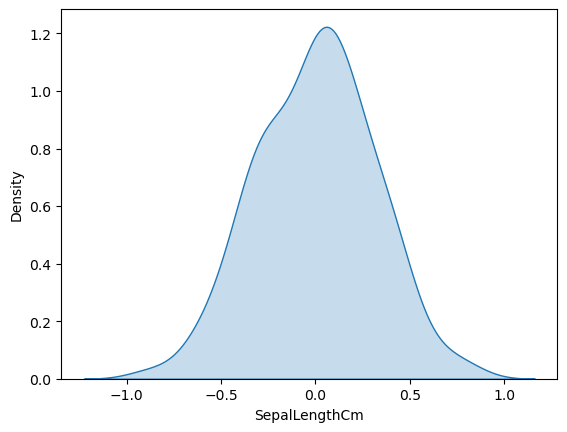

In [53]:
sns.kdeplot(residual_train,fill=True)

<Axes: xlabel='SepalLengthCm', ylabel='Density'>

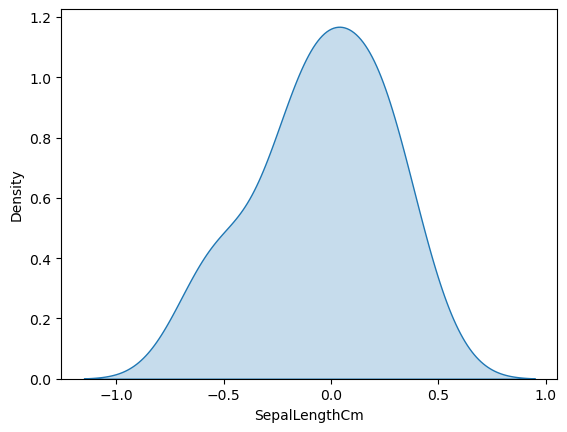

In [54]:
sns.kdeplot(residual_test,fill=True)

In [ ]:
# ks_tets tocheck normlity of residual

In [56]:
from scipy.stats import kstest

In [70]:
_, p_val=kstest(residual_test,"norm")
if p_val >= 0.05:
    print("null hypotheisi i strue")
    print("DAta is normslly distributed")
else:
    print("Alternate hypotheisi is true")

Alternate hypotheisi is true


In [71]:
print(p_val)

0.007049727151767549


In [72]:
# evaluatipo n of training data 
mse=mean_squared_error(y_train,y_pred_train)

In [73]:
mse

0.0950809239233815